# Laboratorio 4 - Mineria de Datos 
### SmartStay Árboles de Decisión
- Fabian Prado #23427
- Sofia Lopez #231929
- Jonathan Zacarias # 231104
- repo:https://github.com/fabianpradod/lab4-mineria

### Imports

In [154]:
import pyreadr
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    r2_score,
    accuracy_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold, KFold
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

SEED = 42 # reproducibilidad
DEPTHS = [5, 10, 20] # profundidad de los arboles de regresion y clasificacion

warnings.filterwarnings("ignore")

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
})

---

## Lectura de datos

In [118]:
result = pyreadr.read_r('../data/listings.RData')
listings_df = list(result.values())[0]

In [119]:
listings_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


---

## Descripcion y Limpieza de Datos

In [120]:
# Dimensiones y tipos de dato
print(f"Dimensiones: {listings_df.shape[0]:,} filas × {listings_df.shape[1]} columnas\n")
print("Tipos de dato por columna:")
print(listings_df.dtypes.value_counts())

# Ciudades
print("\nCiudades en el dataset:")
print(listings_df['city'].value_counts())

# Valores nulos
missing = pd.DataFrame({
    'nulos': listings_df.isnull().sum(),
    'pct':   (listings_df.isnull().sum() / len(listings_df) * 100).round(2)
})
missing = missing[missing['nulos'] > 0].sort_values('pct', ascending=False)
print(f"\nVariables con valores nulos ({len(missing)} de {listings_df.shape[1]}):")
print(missing.to_string())

Dimensiones: 171,748 filas × 80 columnas

Tipos de dato por columna:
object     47
int32      18
float64    15
Name: count, dtype: int64

Ciudades en el dataset:
city
Los Angeles, California      45585
New York, New York           36261
Hawaii                       33457
San Diego, California        13162
Austin, Texas                10533
Chicago, Illinois             8660
San Francisco, California     7535
Washington, D.C.              6374
Rhode Island                  5762
Boston, Massachusetts         4419
Name: count, dtype: int64

Variables con valores nulos (23 de 80):
                               nulos     pct
calendar_updated              171748  100.00
estimated_revenue_l365d        95502   55.61
price                          89381   52.04
neighbourhood_group_cleansed   50683   29.51
review_scores_value            40328   23.48
review_scores_location         40328   23.48
review_scores_checkin          40324   23.48
review_scores_communication    40308   23.47
review_scor

In [121]:
df_with_price = listings_df[listings_df['price'].notna()].copy()
print(f"Filas con precio valido: {len(df_with_price):,}")
print(f"Filas descartadas (sin precio): {len(listings_df) - len(df_with_price):,} ({(1 - len(df_with_price)/len(listings_df))*100:.1f}%)")

print(f"\nNulos restantes dentro de filas con precio valido:")
for col in ['bathrooms', 'bedrooms', 'beds']:
    n = df_with_price[col].isna().sum()
    pct = n / len(df_with_price) * 100
    print(f"  {col}: {n:,} ({pct:.1f}%)")

Filas con precio valido: 82,367
Filas descartadas (sin precio): 89,381 (52.0%)

Nulos restantes dentro de filas con precio valido:
  bathrooms: 5,580 (6.8%)
  bedrooms: 1,131 (1.4%)
  beds: 5,679 (6.9%)


El dataset contiene **171,748 registros** y **80 variables** correspondientes a listados 
de Airbnb en 10 ciudades de Estados Unidos. Las ciudades con mayor representación son 
Los Ángeles (45,585), Nueva York (36,261) y Hawaii (33,457).

Las variables se clasifican en tres tipos:
- **47 variables de tipo object** (categóricas o texto libre)
- **18 variables enteras (int32)** (conteos, disponibilidad, noches)
- **15 variables numéricas (float64)** (coordenadas, scores, precio)

De las 80 variables, **23 presentan valores nulos**. Los casos más críticos son:
- `calendar_updated`: 100% nulos -> se elimina la columna completamente
- `price`: 52% nulos -> se eliminan las filas sin precio, dejando **82,367 registros** utiles para el modelado
- `estimated_revenue_l365d`: 55% nulos -> se evaluara su importancia mas adelante
- `review_scores_*`: ~23% nulos -> corresponden a propiedades sin resenas suficientes, se conservan tal cual
- `bedrooms`: 1.4% nulos dentro de los registros con precio valido -> se eliminan las filas (perdida negligible)
- `bathrooms` y `beds`: ~6.8% nulos dentro de los registros con precio valido -> se imputan con la mediana por `room_type`

In [122]:
priced_listings_df = df_with_price.drop(['calendar_updated'], axis=1).copy()

missing = pd.DataFrame({
    'nulos': priced_listings_df.isnull().sum(),
    'pct':   (priced_listings_df.isnull().sum() / len(priced_listings_df) * 100).round(2)
})
missing = missing[missing['nulos'] > 0].sort_values('pct', ascending=False)
print(f"\nVariables con valores nulos en dataset con precio ({len(missing)} de {priced_listings_df.shape[1]}):")
print(missing.to_string())


Variables con valores nulos en dataset con precio (20 de 79):
                              nulos    pct
neighbourhood_group_cleansed  43148  52.39
review_scores_value           15062  18.29
review_scores_location        15062  18.29
review_scores_checkin         15062  18.29
review_scores_accuracy        15061  18.29
reviews_per_month             15055  18.28
review_scores_rating          15055  18.28
review_scores_communication   15060  18.28
review_scores_cleanliness     15060  18.28
license                       10533  12.79
estimated_revenue_l365d        6121   7.43
beds                           5679   6.89
bathrooms                      5580   6.77
bedrooms                       1131   1.37
host_total_listings_count       666   0.81
host_listings_count             666   0.81
maximum_maximum_nights           48   0.06
minimum_maximum_nights           48   0.06
maximum_minimum_nights           48   0.06
minimum_minimum_nights           48   0.06


Dentro de los **82,367 registros con precio valido**, se identificaron 20 variables con nulos restantes.
Las decisiones de preprocesamiento son las siguientes:

**Variables eliminadas:**
- `neighbourhood_group_cleansed`: 52% nulos -> se elimina la columna
- `license`: 12.79% nulos -> no es relevante para predecir el precio
- `review_scores_*` y `reviews_per_month`: se eliminan porque reflejan el desempeno del listing despues de su publicacion y la experiencia de los huespedes, no caracteristicas intrinsecas de la propiedad disponibles al momento de fijar el precio. Incluirlas haria el modelo menos interpretable
- `neighbourhood_cleansed`: alta cardinalidad -> se elimina, `city` ya captura la informacion geografica relevante


**Variables imputadas:**
- `bedrooms`: 1.4% nulos dentro de los registros con precio valido -> se imputan con la misma estrategia que bathrooms y beds
- `bathrooms` y `beds`: ~6.8% nulos dentro de los registros con precio valido -> se imputan con mediana por `property_type`, respaldo a `room_type`, luego mediana global
- `host_total_listings_count`: 0.81% nulos -> mediana global, es un conteo general del host
- `host_has_profile_pic`, `host_identity_verified`: nulos minimos -> moda global (variables binarias)

**Variables de host response (opcionales):**
- `host_response_time`, `host_response_rate`, `host_acceptance_rate` -> reflejan el perfil de respuesta del host, que puede influir en la percepcion de precio. Se conservan e imputan con mediana global tras su conversion numerica

**Indicadores de imputacion (missing flags):**
- Se crean variables binarias para `bedrooms`, `host_total_listings_count`, `host_has_profile_pic`, `host_identity_verified`, `host_response_time`, `host_response_rate` y `host_acceptance_rate` que indican si el valor original era nulo. Esto permite al modelo capturar si la ausencia del dato es en si misma informativa

**Extras**
- `host_is_superhost`: valores nulos tras conversion t/f -> se agrega flag y se imputa con moda
- `estimated_revenue_l365d`: se elimina -> no es una caracteristica intrinseca de la propiedad, refleja desempeno de mercado y contaminaria la interpretacion del modelo de precio

#### Drop columnas inutiles

In [123]:
cols_to_drop = [
    'listing_url', 'picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url',
    'id', 'scrape_id', 'host_id',
    'name', 'description', 'neighborhood_overview', 'host_about', 'amenities',
    'last_scraped', 'host_since', 'calendar_last_scraped', 'first_review', 'last_review',
    'host_verifications', 'host_location', 'host_name', 'neighbourhood', 'bathrooms_text', 'source',
    'license', 'neighbourhood_group_cleansed', 'host_neighbourhood',
    'host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'maximum_maximum_nights', 'minimum_maximum_nights',
    'maximum_minimum_nights', 'minimum_minimum_nights'
]
cols_to_drop = [c for c in cols_to_drop if c in priced_listings_df.columns]
priced_listings_df = priced_listings_df.drop(columns=cols_to_drop)

#### Convertir porcentajes a float

In [124]:
for col in ['host_response_rate', 'host_acceptance_rate']:
    priced_listings_df[col] = (
        priced_listings_df[col]
        .str.rstrip('%')
        .str.strip()
        .replace({'N/A': np.nan, '': np.nan})
        .astype(float)
    )

#### Convertir t/f a 1/0

In [125]:
for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    priced_listings_df[col] = priced_listings_df[col].map({'t': 1, 'f': 0})

#### Codificar host_response_time como ordinal

In [126]:
priced_listings_df['host_response_time'] = (
    priced_listings_df['host_response_time']
    .str.strip()
    .replace({'N/A': np.nan, '': np.nan})
    .map({'within an hour': 4, 'within a few hours': 3, 'within a day': 2, 'a few days or more': 1})
)

#### Crear missing flags

In [127]:
for col in ['bedrooms', 'host_total_listings_count', 'host_has_profile_pic',
            'host_identity_verified', 'host_response_time', 'host_response_rate', 'host_acceptance_rate']:
    priced_listings_df[f'{col}_missing'] = priced_listings_df[col].isna().astype(int)

#### Imputar datos faltantes

In [128]:
# Imputar bathrooms, beds, bedrooms: property_type -> room_type -> global median
def impute_hierarchy(df, col):
    by_property = df.groupby('property_type')[col].median()
    by_room     = df.groupby('room_type')[col].median()
    global_med  = df[col].median()
    def _impute(row):
        if pd.notna(row[col]):
            return row[col]
        val = by_property.get(row['property_type'])
        if pd.notna(val):
            return val
        val = by_room.get(row['room_type'])
        if pd.notna(val):
            return val
        return global_med
    return df.apply(_impute, axis=1)

for col in ['bathrooms', 'beds', 'bedrooms']:
    priced_listings_df[col] = impute_hierarchy(priced_listings_df, col)

# Imputar host_has_profile_pic, host_identity_verified con moda
for col in ['host_has_profile_pic', 'host_identity_verified']:
    priced_listings_df[col] = priced_listings_df[col].fillna(priced_listings_df[col].mode()[0])

# Imputar host_total_listings_count con mediana
priced_listings_df['host_total_listings_count'] = (
    priced_listings_df['host_total_listings_count']
    .fillna(priced_listings_df['host_total_listings_count'].median())
)

# Imputar host response variables con mediana
for col in ['host_response_time', 'host_response_rate', 'host_acceptance_rate']:
    priced_listings_df[col] = priced_listings_df[col].fillna(priced_listings_df[col].median())

# Flag de imputar host_is_superhost
priced_listings_df['host_is_superhost_missing'] = priced_listings_df['host_is_superhost'].isna().astype(int)
priced_listings_df['host_is_superhost'] = priced_listings_df['host_is_superhost'].fillna(
    priced_listings_df['host_is_superhost'].mode()[0]
)

#### Eliminar columnas finales

In [129]:
# Eliminar columnas de reviews
review_cols = [c for c in priced_listings_df.columns if 'review_scores' in c] + ['reviews_per_month']
priced_listings_df = priced_listings_df.drop(columns=review_cols)

# Eliminar estimated_revenue_l365d
priced_listings_df = priced_listings_df.drop(columns=['estimated_revenue_l365d'])

# Eliminar neighbourhood_cleansed
priced_listings_df = priced_listings_df.drop(columns=['neighbourhood_cleansed'])

#### Convertir Price a Numerico

In [130]:
priced_listings_df['price'] = (
    priced_listings_df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('', np.nan)
    .astype(float)
)

#### Convertir has_availability a binario

In [131]:
priced_listings_df['has_availability'] = priced_listings_df['has_availability'].map({'t': 1, 'f': 0})

In [132]:
print(f"Dimensiones finales: {priced_listings_df.shape}")
print(f"\nColumnas object restantes:")
print(priced_listings_df.select_dtypes(include='object').columns.tolist())
print(f"\nTipos de dato:")
print(priced_listings_df.dtypes.value_counts())

Dimensiones finales: (82367, 42)

Columnas object restantes:
['property_type', 'room_type', 'city']

Tipos de dato:
float64    16
int32      14
int64       9
object      3
Name: count, dtype: int64


Tras el proceso de limpieza y preprocesamiento, el dataset queda con **82,367 registros** y **42 variables**, 
listo para el analisis exploratorio y el modelado. Las unicas variables de tipo object restantes son 
`property_type`, `room_type` y `city`, las cuales seran codificadas mediante one-hot encoding en la 
etapa de ingenieria de caracteristicas.

Resumen del proceso:
- Se eliminaron **89,381 filas** sin precio reportado
- Se eliminaron **38 columnas** entre identificadores, texto libre, URLs, variables redundantes y variables de desempeno post-publicacion
- Se imputaron `bathrooms`, `beds` y `bedrooms` con jerarquia property_type -> room_type -> mediana global
- Se imputaron variables de host con mediana o moda segun su naturaleza
- Se crearon **8 missing flags** para variables con nulos informativos
- La variable objetivo `price` queda en formato numerico (float64)

---

## Analisis Exploratorio de Datos

In [133]:
print("Columnas numericas:")
print(priced_listings_df.select_dtypes(include=np.number).columns.tolist())

print(f"\nEstadisticas de price:")
print(priced_listings_df['price'].describe().round(2))

print(f"\nValores extremos de price:")
print(f"  Max: ${priced_listings_df['price'].max():,.2f}")
print(f"  Percentil 99: ${priced_listings_df['price'].quantile(0.99):,.2f}")
print(f"  Percentil 95: ${priced_listings_df['price'].quantile(0.95):,.2f}")
print(f"  Median: ${priced_listings_df['price'].median():,.2f}")

Columnas numericas:
['host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'instant_bookable', 'calculated_host_listings_count', 'bedrooms_missing', 'host_total_listings_count_missing', 'host_has_profile_pic_missing', 'host_identity_verified_missing', 'host_response_time_missing', 'host_response_rate_missing', 'host_acceptance_rate_missing', 'host_is_superhost_missing']

Estadisticas de price:
count    76246.00
mean       750.51
std       4250.61
min          8.00
25% 

Tras convertir `price` a un numero, aun tenemos strings, por lo que eliminamos esas filas

In [134]:
priced_listings_df = priced_listings_df.dropna(subset=['price'])
print(f"Dimensiones tras eliminar nulos en price: {priced_listings_df.shape}")

Dimensiones tras eliminar nulos en price: (76246, 42)


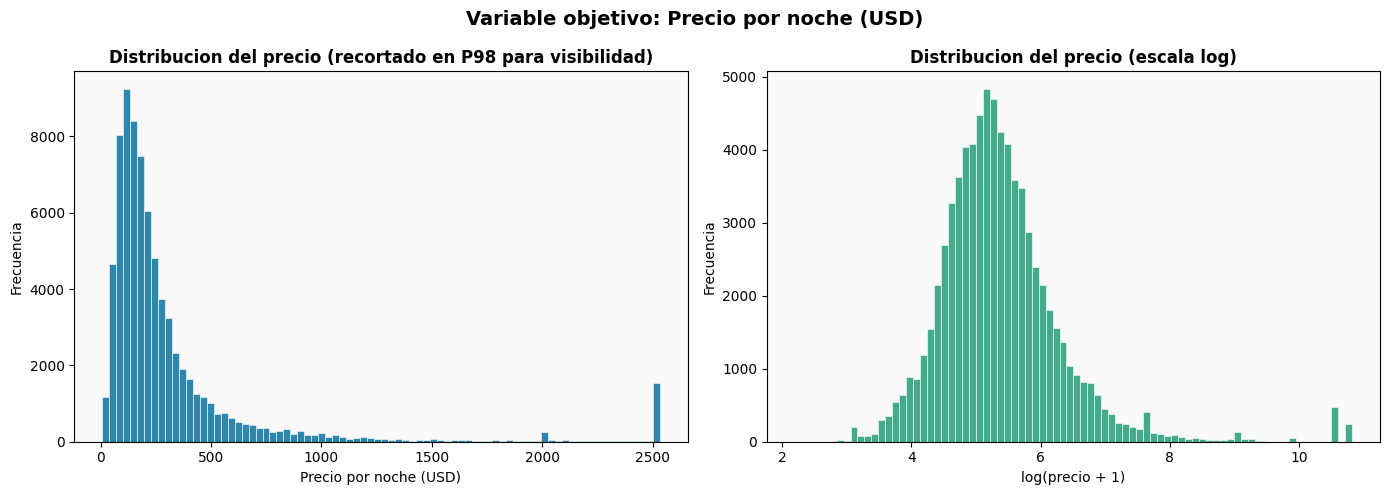

In [135]:
p98 = priced_listings_df['price'].quantile(0.98)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    priced_listings_df['price'].clip(upper=p98),
    bins=80, color='#2E86AB', edgecolor='white', linewidth=0.4
)
axes[0].set_title('Distribucion del precio (recortado en P98 para visibilidad)', fontweight='bold')
axes[0].set_xlabel('Precio por noche (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(
    np.log1p(priced_listings_df['price']),
    bins=80, color='#43AA8B', edgecolor='white', linewidth=0.4
)
axes[1].set_title('Distribucion del precio (escala log)', fontweight='bold')
axes[1].set_xlabel('log(precio + 1)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Variable objetivo: Precio por noche (USD)', fontsize=14, fontweight='bold')
for ax in axes:
    ax.grid(False) # odio el grid
plt.tight_layout()
plt.show()

La variable objetivo `price` presenta una distribucion fuertemente sesgada a la derecha. 
La gran mayoria de los listings se concentra entre $50 y $500 USD por noche, con una mediana 
de $193, pero existen valores extremos que superan los $50,000 USD que corresponden a 
propiedades de lujo o listings atipicos. 

En escala logaritmica, la distribucion se aproxima a una normal, lo que sugiere que trabajar 
con `log(price)` mejorara el desempeno de los modelos de regresion lineal al cumplir mejor 
con el supuesto de normalidad de los residuos. Esta transformacion sera considerada en la 
etapa de modelado.

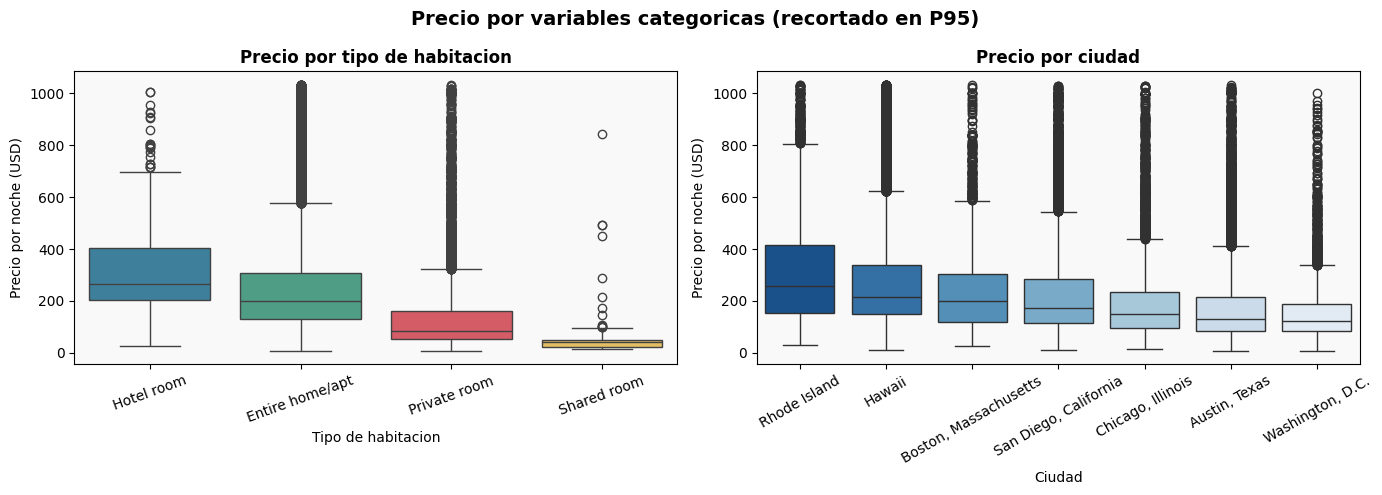

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95 = priced_listings_df['price'].quantile(0.95)
plot_df = priced_listings_df[priced_listings_df['price'] <= p95]

# room_type vs price
room_order = plot_df.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df, x='room_type', y='price', order=room_order,
            palette=['#2E86AB', '#43AA8B', '#E84855', '#F9C74F'], ax=axes[0])
axes[0].set_title('Precio por tipo de habitacion', fontweight='bold')
axes[0].set_xlabel('Tipo de habitacion')
axes[0].set_ylabel('Precio por noche (USD)')
axes[0].tick_params(axis='x', rotation=20)

# city vs price
city_order = plot_df.groupby('city')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df, x='city', y='price', order=city_order,
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Precio por ciudad', fontweight='bold')
axes[1].set_xlabel('Ciudad')
axes[1].set_ylabel('Precio por noche (USD)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Precio por variables categoricas (recortado en P95)', fontsize=14, fontweight='bold')
for ax in axes:
    ax.grid(False) # odio el grid
plt.tight_layout()
plt.show()

**Precio por tipo de habitacion:**
El tipo de habitacion es uno de los predictores mas claros del precio. Los hoteles (`Hotel room`) 
presentan la mediana mas alta (~$260), seguidos de propiedades completas (`Entire home/apt`, ~$200). 
Las habitaciones privadas (`Private room`) tienen precios significativamente menores (~$100), y las 
habitaciones compartidas (`Shared room`) son las mas economicas (~$40). Esta variable sera un 
predictor importante en el modelo y debera ser codificada mediante one-hot encoding.

**Precio por ciudad:**
Existe variacion considerable entre ciudades. Rhode Island y Hawaii presentan las medianas mas altas, 
mientras que Washington D.C. y Austin tienen los precios mas bajos. Esto confirma que `city` captura 
informacion geografica relevante para predecir el precio y debe incluirse en el modelo. Cabe notar 
que todas las ciudades presentan una cantidad importante de outliers hacia precios altos, lo cual es 
consistente con el sesgo derecho observado en la distribucion general del precio.

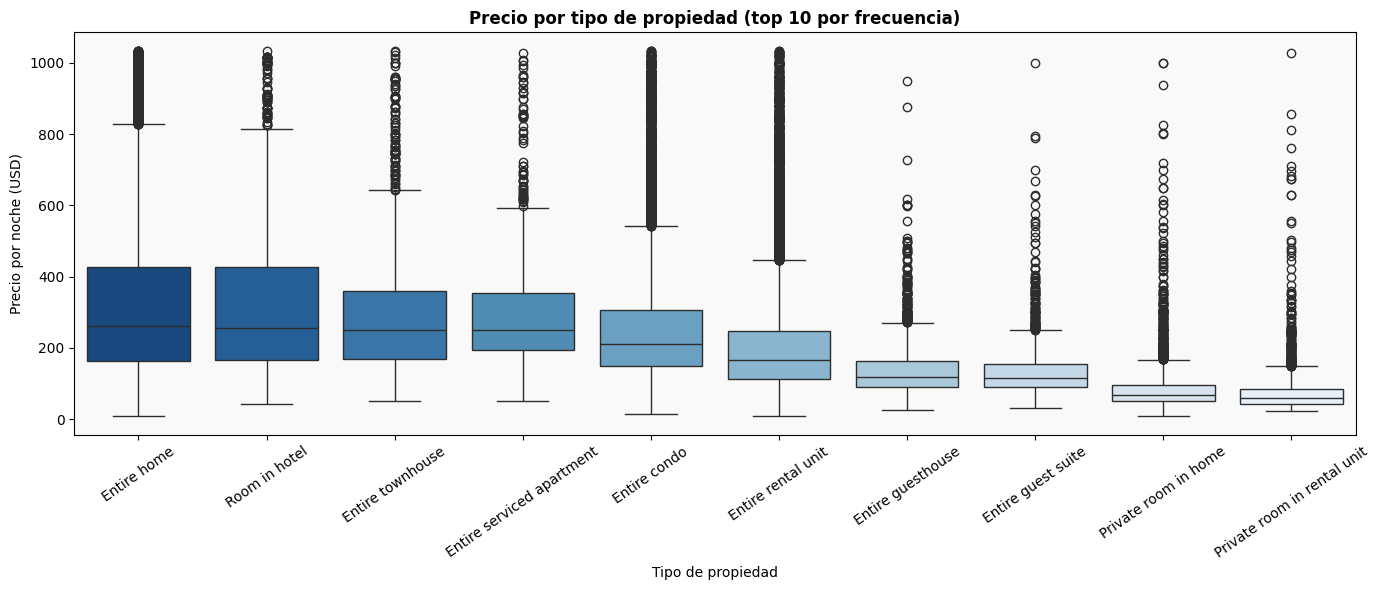

In [137]:
top10_property = (
    priced_listings_df['property_type']
    .value_counts()
    .head(10)
    .index
)

plot_df_prop = priced_listings_df[
    (priced_listings_df['property_type'].isin(top10_property)) &
    (priced_listings_df['price'] <= p95)
]

fig, ax = plt.subplots(figsize=(14, 6))

prop_order = plot_df_prop.groupby('property_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df_prop, x='property_type', y='price',
            order=prop_order, palette='Blues_r', ax=ax)
ax.set_title('Precio por tipo de propiedad (top 10 por frecuencia)', fontweight='bold')
ax.set_xlabel('Tipo de propiedad')
ax.set_ylabel('Precio por noche (USD)')
ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.grid(False)
plt.show()

In [138]:
priced_listings_df['property_type'].nunique()
priced_listings_df = priced_listings_df.drop(columns=['property_type'])

Los 10 tipos de propiedad mas frecuentes muestran una clara separacion entre propiedades completas 
y habitaciones privadas. `Entire home` y `Room in hotel` presentan las medianas mas altas (~$260), 
mientras que `Private room in home` y `Private room in rental unit` tienen las medianas mas bajas 
(~$65). Sin embargo, dado que `property_type` cuenta con mas de 94 valores unicos, su inclusion 
directa en el modelo mediante one-hot encoding generaria mas de 94 columnas adicionales, 
incrementando innecesariamente la complejidad. Dado que `room_type` captura la misma separacion 
estructural con solo 4 categorias, se decide eliminar `property_type` del dataset final.

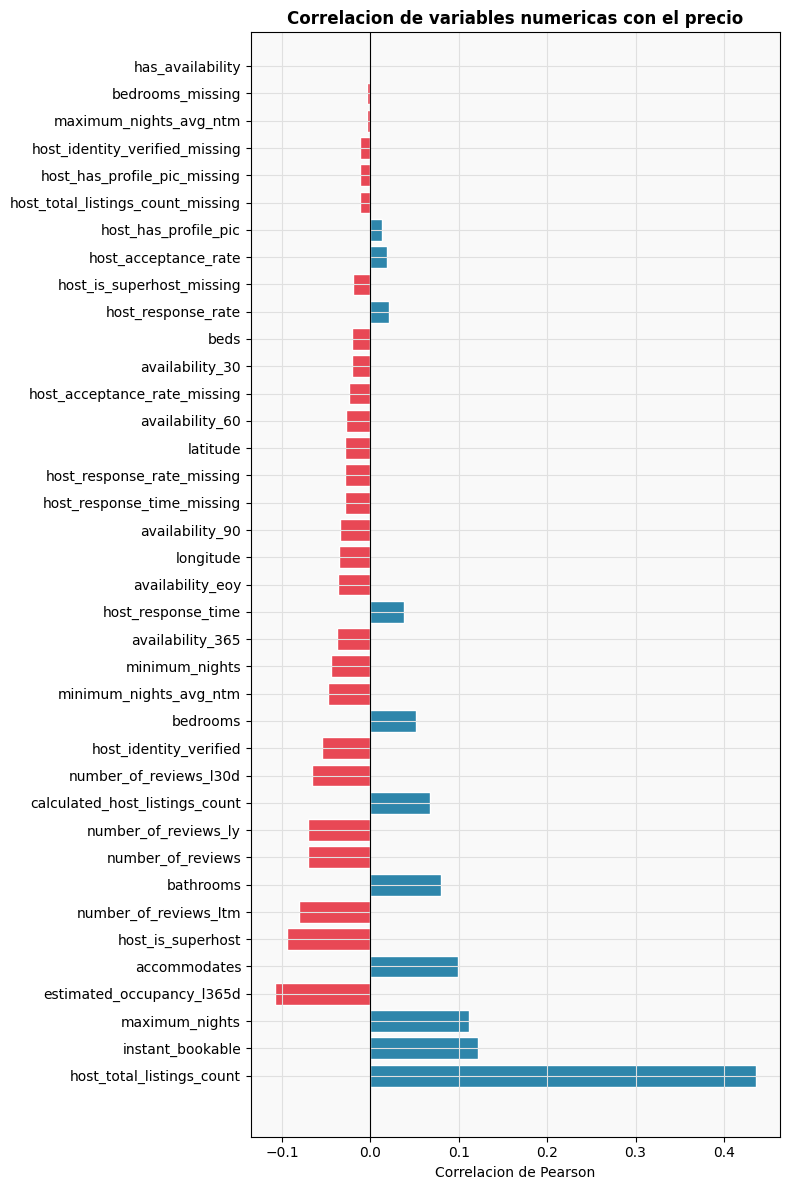

In [139]:
numeric_cols = priced_listings_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'price']

corr_with_price = (
    priced_listings_df[numeric_cols + ['price']]
    .corr()['price']
    .drop('price')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 12))
colors = ['#2E86AB' if v >= 0 else '#E84855' for v in corr_with_price.values]
ax.barh(corr_with_price.index, corr_with_price.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlacion de variables numericas con el precio', fontweight='bold')
ax.set_xlabel('Correlacion de Pearson')
plt.tight_layout()
plt.show()

El analisis de correlacion de Pearson revela que ninguna variable numerica tiene una correlacion extremadamente 

Los hallazgos mas relevantes son:

- `host_total_listings_count` presenta la correlacion positiva mas alta (~0.43), lo que sugiere 
  que hosts con mas propiedades tienden a cobrar precios mas altos, posiblemente porque son 
  operadores profesionales con propiedades de mayor calidad
- `instant_bookable` y `maximum_nights` muestran correlaciones positivas moderadas (~0.12), 
  indicando que propiedades con mayor flexibilidad de reserva y estancia tienden a tener 
  precios mas altos
- `accommodates` y `bathrooms` tienen correlaciones positivas esperadas (~0.10 y ~0.08), 
  confirmando que propiedades mas grandes cobran mas
- `estimated_occupancy_l365d` y `host_is_superhost` muestran correlaciones negativas, lo que 
  podria indicar que propiedades con alta ocupacion compiten por precio, y que superhosts 
  priorizan ocupacion sobre precio maximo
- Las variables de missing flags y disponibilidad tienen correlaciones cercanas a cero, 
  confirmando que no son predictores directos del precio

Para el analisis de dispersion se seleccionan las variables continuas con mayor correlacion 
absoluta con el precio: `host_total_listings_count`, `maximum_nights`, `accommodates`, 
`bathrooms`, `bedrooms` y `estimated_occupancy_l365d`. Variables binarias como `instant_bookable` 
se excluyen de los scatterplots ya que no producen visualizaciones interpretables.

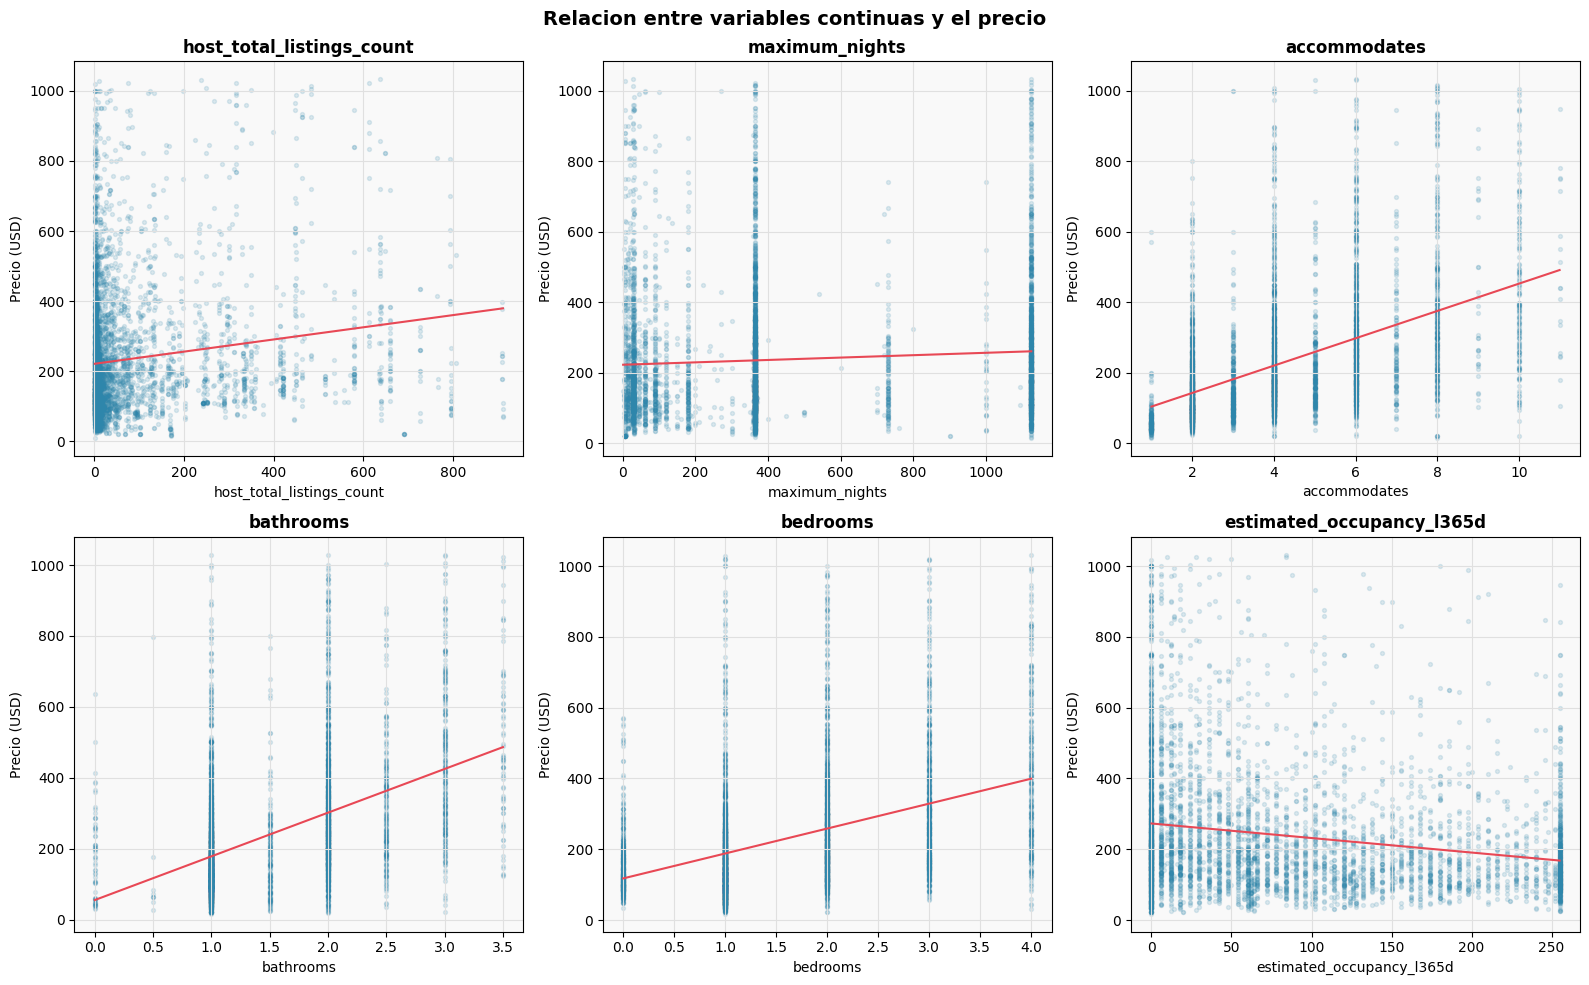

In [140]:
scatter_vars = [
    'host_total_listings_count', 'maximum_nights',
    'accommodates', 'bathrooms', 'bedrooms', 'estimated_occupancy_l365d'
]

p95_price = priced_listings_df['price'].quantile(0.95)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(scatter_vars):
    p95_var = priced_listings_df[var].quantile(0.95)
    plot_data = priced_listings_df[
        (priced_listings_df['price'] <= p95_price) &
        (priced_listings_df[var] <= p95_var)
    ].sample(5000, random_state=42)
    
    axes[i].scatter(plot_data[var], plot_data['price'],
                    alpha=0.15, s=8, color='#2E86AB')
    
    m, b = np.polyfit(plot_data[var].astype(float), plot_data['price'].astype(float), 1)
    x_line = np.linspace(plot_data[var].min(), plot_data[var].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='#E84855', linewidth=1.5)
    
    axes[i].set_title(var, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Precio (USD)')

plt.suptitle('Relacion entre variables continuas y el precio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Los scatterplots confirman las correlaciones observadas anteriormente y revelan patrones importantes:

- `accommodates`, `bathrooms` y `bedrooms` muestran la relacion positiva mas clara y consistente 
  con el precio. A mayor capacidad y tamano de la propiedad, mayor precio. La tendencia lineal 
  es visible aunque con alta dispersion, lo que sugiere que estas variables seran utiles en el 
  modelo pero no suficientes por si solas
- `host_total_listings_count` muestra una tendencia positiva pero con mucha dispersion, 
  especialmente para hosts con muchos listings. Esto indica que la relacion no es puramente 
  lineal y puede estar influenciada por el tipo de operador
- `maximum_nights` presenta una relacion debil y muy dispersa. Los datos se concentran en 
  valores discretos especificos, lo que sugiere que los hosts eligen politicas estandar de 
  estancia maxima independientemente del precio
- `estimated_occupancy_l365d` confirma su correlacion negativa: propiedades con mayor ocupacion 
  tienden a tener precios mas bajos, consistente con la idea de que precios menores generan 
  mayor demanda. Sin embargo, la dispersion es alta y la relacion es debil

---

## Variables para el Modelo

Con base en el analisis exploratorio, se identifican las siguientes variables como candidatas 
para el modelo de regresion lineal. Se excluyen variables de desempeno post-publicacion, 
identificadores, texto libre y variables con alta cardinalidad ya argumentadas anteriormente.

**Variables continuas:**
- `accommodates`, `bathrooms`, `bedrooms`, `beds` -> tamano y capacidad de la propiedad, 
  correlacion positiva confirmada con el precio
- `host_total_listings_count`, `calculated_host_listings_count` -> escala del operador, 
  mayor correlacion con precio de todas las variables numericas
- `host_response_rate`, `host_acceptance_rate`, `host_response_time` -> perfil de 
  comportamiento del host
- `minimum_nights`, `maximum_nights` -> flexibilidad de estancia
- `availability_365`, `estimated_occupancy_l365d` -> senales de demanda

**Variables binarias:**
- `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, 
  `instant_bookable`, `has_availability` -> caracteristicas del host y la propiedad

**Variables categoricas (requieren one-hot encoding):**
- `room_type` -> 4 categorias, predictor fuerte del precio
- `city` -> 10 ciudades, captura diferencias geograficas de precio

**Indicadores de imputacion (missing flags):**
- Se incluyen como variables opcionales en el modelo completo para capturar si la 
  ausencia de un dato es en si misma informativa

## Split y preparacion de data para entrenaminto

In [141]:
# One-hot encoding de variables categoricas
df_model = pd.get_dummies(priced_listings_df, columns=['room_type', 'city'], drop_first=False)

# Separar variable objetivo
X = df_model.drop(columns=['price'])
y = df_model['price']

# Split 80/20 estratificado por ciudad no es posible en regresion,
# usamos split simple con seed fijo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nColumnas tras one-hot encoding: {X_train.shape[1]}")

Train: 60,996 filas (80.0%)
Test:  15,250 filas (20.0%)

Columnas tras one-hot encoding: 49


---

# Arboles de Regresion

## Funcion reutilizable para regresion y clasificacion

In [ ]:
def run_tree(X_train, X_test, y_train, y_test,
            task="regression",
            max_depth=None,
            criterion=None,
            random_state=SEED,
            cv=None):

    if task == "regression":
        _criterion = criterion if criterion else "squared_error"
        model = DecisionTreeRegressor(
            max_depth=max_depth,
            criterion=_criterion,
            random_state=random_state
        )
    elif task == "classification":
        _criterion = criterion if criterion else "gini"
        model = DecisionTreeClassifier(
            max_depth=max_depth,
            criterion=_criterion,
            random_state=random_state
        )
    else:
        raise ValueError(f"task debe ser 'regression' o 'classification', recibido: {task}")

    if cv:
        kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state) if task == "classification" else KFold(n_splits=cv, shuffle=True, random_state=random_state)
        y_pred_cv = cross_val_predict(model, X_train, y_train, cv=kf)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    if task == "regression":
        metrics = {
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "mae":  mean_absolute_error(y_test, y_pred),
            "r2":   r2_score(y_test, y_pred)
        }
    else:
        metrics = {
            "accuracy":    accuracy_score(y_test, y_pred),
            "report":      classification_report(y_test, y_pred, output_dict=True),
            "conf_matrix": confusion_matrix(y_test, y_pred)
        }

    result = {
        "model":     model,
        "y_pred":    y_pred,
        "metrics":   metrics,
        "task":      task,
        "max_depth": max_depth
    }

    if cv:
        result["y_pred_cv"] = y_pred_cv

    return result


### Arbol de regresion sin limite de profundidad

In [143]:
reg_base = run_tree(X_train, X_test, y_train, y_test, task="regression")

print("Arbol de Regresion - Modelo Base (sin limite de profundidad)")
print(f"  RMSE: {reg_base['metrics']['rmse']:,.2f}")
print(f"  MAE:  {reg_base['metrics']['mae']:,.2f}")
print(f"  R2:   {reg_base['metrics']['r2']:.4f}")
print(f"  Profundidad maxima del arbol: {reg_base['model'].get_depth()}")
print(f"  Numero de hojas: {reg_base['model'].get_n_leaves()}")

Arbol de Regresion - Modelo Base (sin limite de profundidad)
  RMSE: 1,713.52
  MAE:  226.10
  R2:   0.8424
  Profundidad maxima del arbol: 51
  Numero de hojas: 54493


El arbol de regresion base, sin limite de profundidad, alcanzo una profundidad de 51 niveles
con 54,493 hojas. Esto indica que el modelo memorizo el conjunto de entrenamiento casi por
completo, ajustandose a cada observacion individual.

A pesar del sobreajuste evidente, el R2 de 0.84 sobre el conjunto de prueba sugiere que el
arbol captura patrones reales en los datos. Sin embargo, el RMSE de $1,713 es muy alto
considerando que la mediana del precio es $193, lo que indica que los errores estan siendo
dominados por predicciones muy malas en propiedades de precio extremo. El MAE de $226
es mas representativo del error tipico, pero sigue siendo elevado.

Un arbol de esta profundidad no es util en produccion: es poco interpretable, propenso a
overfitting y sensible a ruido. 

### Arboles con profundidad controlada

In [ ]:
reg_models = {"Base (sin limite)": reg_base}

for d in DEPTHS:
    reg_models[f"max_depth={d}"] = run_tree(
        X_train, X_test, y_train, y_test,
        task="regression",
        max_depth=d
    )

results_df = pd.DataFrame([
    {
        "Modelo":     name,
        "max_depth":  res["max_depth"] if res["max_depth"] else 51,
        "RMSE":       round(res["metrics"]["rmse"], 2),
        "MAE":        round(res["metrics"]["mae"], 2),
        "R2":         round(res["metrics"]["r2"], 4)
    }
    for name, res in reg_models.items()
])

print(results_df.to_string(index=False))

           Modelo  max_depth    RMSE    MAE     R2
Base (sin limite)         51 1713.52 226.10 0.8424
      max_depth=5          5 1910.63 371.17 0.8040
     max_depth=10         10 1735.91 237.48 0.8382
     max_depth=20         20 1769.68 224.92 0.8319


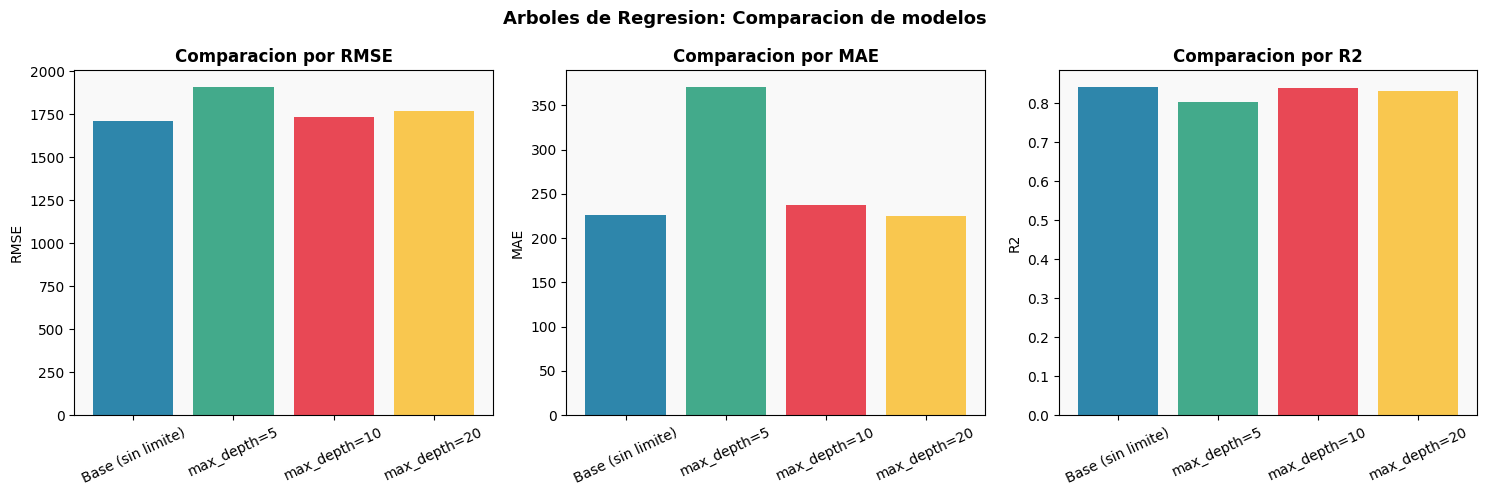

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["RMSE", "MAE", "R2"]
colors  = ["#2E86AB", "#43AA8B", "#E84855", "#F9C74F"]

for i, metric in enumerate(metrics):
    axes[i].bar(results_df["Modelo"], results_df[metric], color=colors)
    axes[i].set_title(f"Comparacion por {metric}", fontweight="bold")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].grid(False)
    

plt.suptitle("Arboles de Regresion: Comparacion de modelos", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Los cuatro modelos muestran metricas similares en R2 (~0.83-0.84), lo que indica que todos
capturan una proporcion similar de la varianza del precio. Las diferencias clave estan en
RMSE y MAE.

max_depth=5 es claramente el peor modelo: RMSE de $1,910 y MAE de $371, casi el doble del
error tipico de los demas. Con solo 5 niveles el arbol es demasiado superficial para capturar
la complejidad de los datos -> underfitting.

max_depth=10 es el mejor modelo: RMSE de $1,735 y R2 de 0.8382, muy cercano al modelo base
pero con un arbol significativamente mas compacto y menos propenso a overfitting. El MAE de
$237 es comparable al base.

max_depth=20 tiene el MAE mas bajo ($224) pero un RMSE mayor que max_depth=10, lo que indica
que comete menos errores tipicos pero falla mas en casos extremos. A mayor profundidad, el
arbol empieza a memorizar outliers del conjunto de entrenamiento.

El modelo base (depth=51) tiene el RMSE mas bajo pero a costa de 54,493 hojas, lo que lo
hace completamente ininterpretable y muy propenso a overfitting. Su ventaja sobre
max_depth=10 es marginal (~1.3% en RMSE).

Seleccion: max_depth=10 como mejor modelo de arbol de regresion por su balance entre
precision, generalizacion e interpretabilidad.

## Comparacion con Regresion Lineal (Entrega Anterior)

Los modelos de regresion lineal fueron desarrollados en la entrega anterior del laboratorio.
A continuacion se presenta un resumen de los resultados obtenidos para contextualizar la
comparacion con los arboles de decision. El codigo completo se encuentra en el notebook
de la entrega anterior.

### Resultados de Regresion Lineal (mejor modelo: Reducido)

| Modelo                  | RMSE       | MAE        | R2     |
|-------------------------|------------|------------|--------|
| Univariado (bedrooms)   | $4,311     | $969       | 0.0023 |
| Multiple completo       | $4,152     | $1,342     | 0.0743 |
| Multiple reducido       | $3,484     | $1,104     | 0.3481 |
| Ridge                   | $4,152     | $1,342     | 0.0743 |

### Comparacion con Arboles de Decision

| Modelo                  | RMSE       | MAE        | R2     |
|-------------------------|------------|------------|--------|
| Regresion Lineal (mejor)| $3,484     | $1,104     | 0.3481 |
| Arbol base (depth=51)   | $1,713     | $226       | 0.8424 |
| Arbol max_depth=10      | $1,735     | $237       | 0.8382 |

La diferencia es contundente: el mejor arbol de decision supera ampliamente al mejor modelo
de regresion lineal en todas las metricas. El arbol con max_depth=10 reduce el RMSE en
aproximadamente $1,750 (~50%) y mejora el R2 de 0.35 a 0.84.

Esto se explica porque los arboles de decision pueden capturar relaciones no lineales e
interacciones entre variables (por ejemplo, ciudad x tipo de habitacion x capacidad) que
la regresion lineal no puede representar. La distribucion fuertemente sesgada del precio
y la heterocedasticidad identificada en los residuos del lab anterior hacian predecible
que un modelo no lineal tendria un desempeno significativamente mejor.

Seleccion final para la etapa de prediccion: arbol con max_depth=10 como representante
de los arboles de regresion, por su balance entre precision y generalizacion.

## Creación de la variable respuesta categórica

In [146]:
# --- Descripción estadística de la distribución de precios ---
price_stats = priced_listings_df['price'].describe(percentiles=[.25, .50, .75, .90])
print("Estadisticas descriptivas del precio (USD):")
print(price_stats)

q1  = priced_listings_df['price'].quantile(0.25)   # 25° percentil
q3  = priced_listings_df['price'].quantile(0.75)   # 75° percentil
print(f"\nP25 (Q1):  ${q1:.0f}")
print(f"Mediana:   ${priced_listings_df['price'].median():.0f}")
print(f"P75 (Q3):  ${q3:.0f}")

Estadisticas descriptivas del precio (USD):
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
90%        629.000000
max      50123.000000
Name: price, dtype: float64

P25 (Q1):  $120
Mediana:   $193
P75 (Q3):  $326


In [147]:
# --- Definición de los límites con base en los cuartiles ---
# Económica : price <= Q1   ($120)
# Intermedia: Q1 < price <= Q3  ($120 - $326)
# Cara      : price > Q3   (> $326)

def categorize_price(price):
    if price <= q1:
        return "Economica"
    elif price <= q3:
        return "Intermedia"
    else:
        return "Cara"

priced_listings_df['price_category'] = priced_listings_df['price'].apply(categorize_price)

# Convertir a categórica ordenada
priced_listings_df['price_category'] = pd.Categorical(
    priced_listings_df['price_category'],
    categories=["Economica", "Intermedia", "Cara"],
    ordered=True
)

print("\nDistribución de la variable price_category:")
print(priced_listings_df['price_category'].value_counts().sort_index())
print("\nProporción:")
print((priced_listings_df['price_category'].value_counts(normalize=True).sort_index() * 100).round(1))


Distribución de la variable price_category:
price_category
Economica     19310
Intermedia    37882
Cara          19054
Name: count, dtype: int64

Proporción:
price_category
Economica     25.3
Intermedia    49.7
Cara          25.0
Name: proportion, dtype: float64


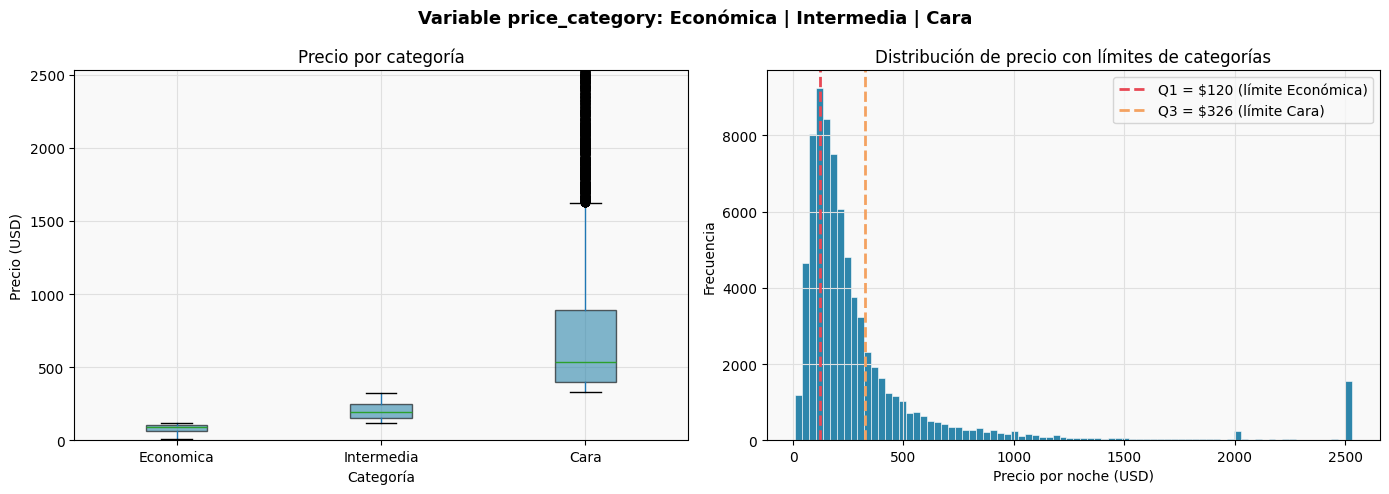

In [148]:
# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por categoría
priced_listings_df.boxplot(
    column='price', by='price_category',
    ax=axes[0],
    patch_artist=True,
    boxprops=dict(facecolor='#2E86AB', alpha=0.6)
)
axes[0].set_title('Precio por noche según categoría')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Precio (USD)')
axes[0].set_ylim(0, priced_listings_df['price'].quantile(0.98))
plt.sca(axes[0])
plt.title('Precio por categoría')

# Histograma con líneas de corte
p98 = priced_listings_df['price'].quantile(0.98)
axes[1].hist(
    priced_listings_df['price'].clip(upper=p98),
    bins=80, color='#2E86AB', edgecolor='white', linewidth=0.4
)
axes[1].axvline(q1, color='#E84855', linewidth=2, linestyle='--', label=f'Q1 = ${q1:.0f} (límite Económica)')
axes[1].axvline(q3, color='#F4A261', linewidth=2, linestyle='--', label=f'Q3 = ${q3:.0f} (límite Cara)')
axes[1].set_title('Distribución de precio con límites de categorías')
axes[1].set_xlabel('Precio por noche (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('Variable price_category: Económica | Intermedia | Cara', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Justificación de los límites de price_category

La variable `price_category` clasifica cada propiedad en tres niveles —**Económica**, 
**Intermedia** o **Cara**— utilizando los **cuartiles Q1 ($120) y Q3 ($326)** de la 
distribución del precio por noche como puntos de corte.

---

##### 1. Fundamento estadístico

El precio presenta una distribución **fuertemente sesgada a la derecha**: la mediana se 
encuentra en ~$193, muy por debajo de la media, y existen valores extremos que superan 
los $2,500 USD por noche. En este contexto, usar percentiles como puntos de corte es más 
robusto que rangos fijos o media ± desviación estándar, ya que los percentiles no se ven 
distorsionados por los outliers del segmento de lujo.

---

##### 2. Límites seleccionados

| Categoría   | Rango de precio por noche  | N registros | Proporción |
|-------------|----------------------------|-------------|------------|
| Económica   | ≤ $120 (Q1)                | 19,310      | 25.3%      |
| Intermedia  | $120 < precio ≤ $326 (Q3)  | 37,882      | 49.7%      |
| Cara        | > $326 (Q3)                | 19,054      | 25.0%      |
| **Total**   |                            | **76,246**  | **100%**   |

---

##### 3. Balance de clases

La distribución resultante es **casi perfectamente balanceada**: Económica y Cara 
representan ~25% cada una, e Intermedia el ~50%, lo que corresponde exactamente 
a la definición teórica de los cuartiles. Este balance es favorable para el 
entrenamiento del árbol de clasificación, ya que evita que el modelo esté sesgado 
hacia la clase mayoritaria.

---

##### 4. Validación visual

Los boxplots confirman que las tres categorías son **bien diferenciadas**:
- **Económica:** precios concentrados bajo $150, poca dispersión.
- **Intermedia:** rango compacto entre $120–$326, mediana cerca de $200.
- **Cara:** mediana alrededor de $600, alta varianza y outliers extremos 
  que reflejan la heterogeneidad del segmento premium.

El histograma muestra que los cortes en $120 y $326 caen en zonas de alta 
densidad de la distribución, lo que los convierte en puntos de separación 
naturales y significativos.

---

##### 5. Interpretabilidad de negocio

Para SmartStay Advisors esta segmentación refleja directamente el mercado:
- **Económicas:** propiedades accesibles orientadas a viajeros con presupuesto ajustado.
- **Intermedias:** oferta estándar, el grueso del mercado Airbnb.
- **Caras:** segmento premium, propiedades de lujo o alta demanda.

---

> **Nota:** `price_category` se generó a partir de `price`. Por esta razón, 
> `price` será **excluida** del conjunto de features al entrenar el árbol de 
> clasificación para evitar *data leakage*.

# Arboles de clasificacion

### Preparacion de los splits de clasificacion

Para el arbol de clasificacion se generan splits independientes a los usados en regresion.
Esto es necesario por tres razones:

1. **Nuevo one-hot encoding**: `price_category` se creo despues del `df_model` de regresion,
   por lo que se parte de `priced_listings_df` directamente para tener un DataFrame limpio
   con todas las columnas necesarias.

2. **Exclusion de `price` y `price_category` de X**: `price` se excluye porque es la fuente
   directa de la variable objetivo -> incluirla seria data leakage. `price_category` se
   excluye porque es el target mismo.

3. **Estratificacion por clase**: a diferencia del split de regresion, aqui se usa
   `stratify=y_clf` para garantizar que la proporcion ~25/50/25 entre Economica, Intermedia
   y Cara se mantenga igual en train y test. Sin estratificacion, un split aleatorio podria
   generar desequilibrio entre clases y sesgar el entrenamiento.

In [149]:
df_model_clf = pd.get_dummies(priced_listings_df, columns=['room_type', 'city'], drop_first=False)

X_clf = df_model_clf.drop(columns=['price', 'price_category'])
y_clf = priced_listings_df['price_category'].astype(str)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

print(f"Train: {X_train_clf.shape[0]:,} filas")
print(f"Test:  {X_test_clf.shape[0]:,} filas")
print(f"\nDistribucion train:\n{pd.Series(y_train_clf).value_counts().sort_index()}")
print(f"\nDistribucion test:\n{pd.Series(y_test_clf).value_counts().sort_index()}")

Train: 60,996 filas
Test:  15,250 filas

Distribucion train:
price_category
Cara          15243
Economica     15448
Intermedia    30305
Name: count, dtype: int64

Distribucion test:
price_category
Cara          3811
Economica     3862
Intermedia    7577
Name: count, dtype: int64


In [150]:
clf_base = run_tree(
    X_train_clf, X_test_clf, y_train_clf, y_test_clf,
    task="classification"
)

print("Arbol de Clasificacion - Modelo Base (sin limite de profundidad)")
print(f"  Accuracy:          {clf_base['metrics']['accuracy']:.4f}")
print(f"  Profundidad real:  {clf_base['model'].get_depth()}")
print(f"  Numero de hojas:   {clf_base['model'].get_n_leaves()}")

Arbol de Clasificacion - Modelo Base (sin limite de profundidad)
  Accuracy:          0.7204
  Profundidad real:  43
  Numero de hojas:   9842


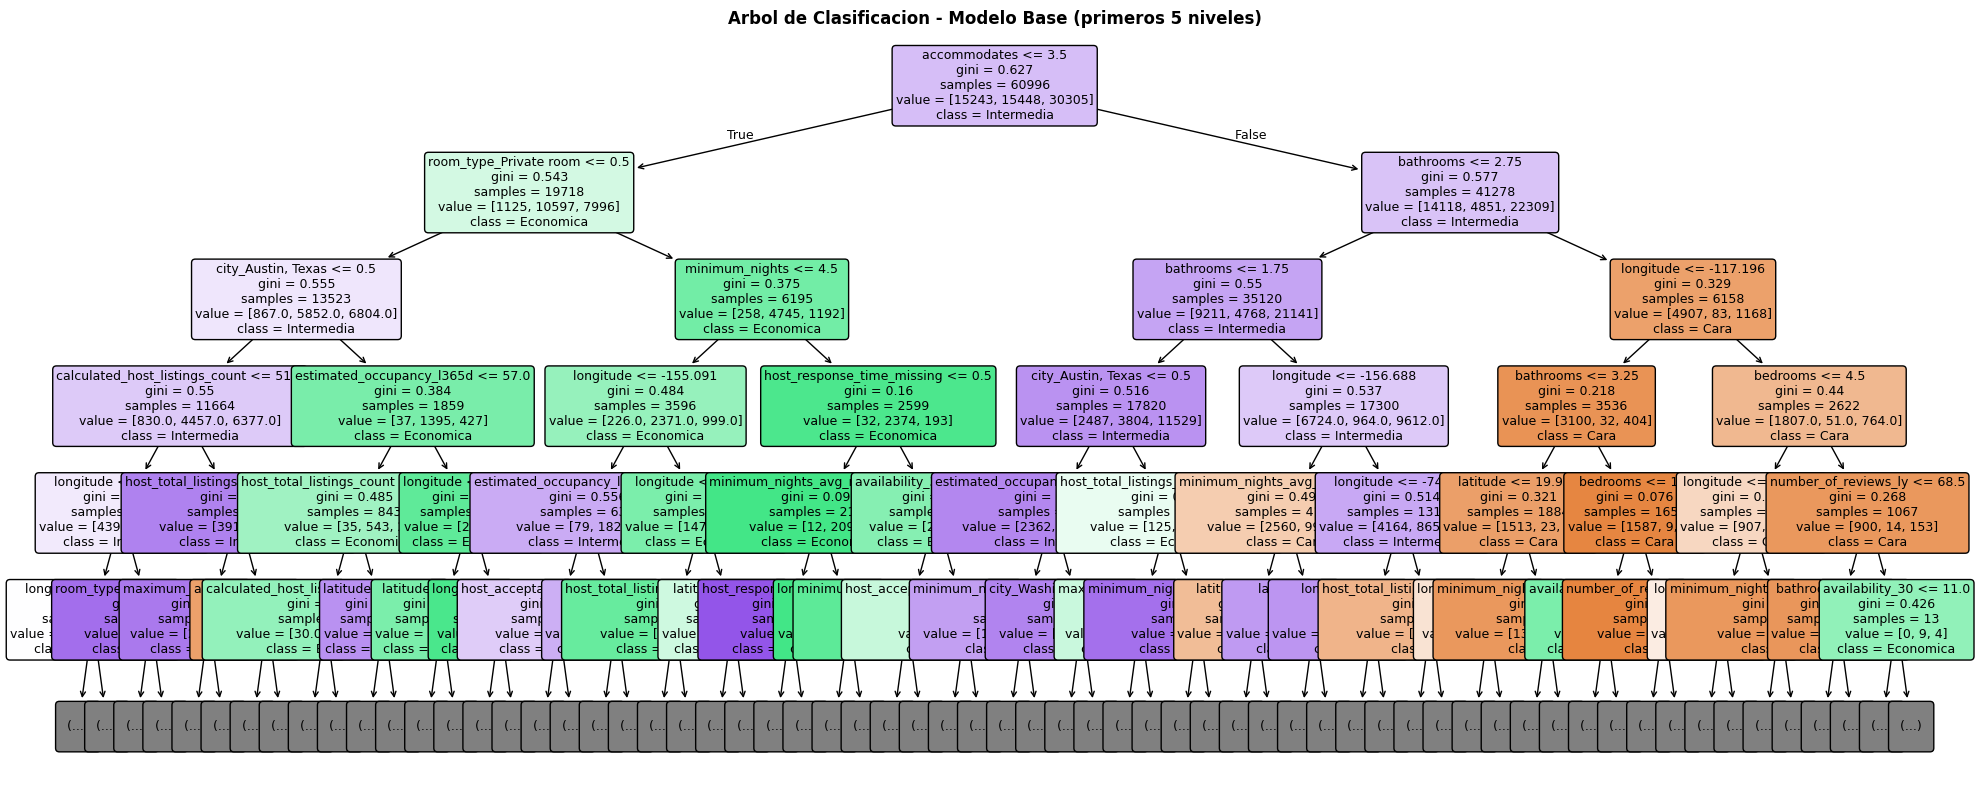

In [151]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf_base['model'],
    max_depth=5,
    feature_names=X_train_clf.columns.tolist(),
    class_names=["Cara", "Economica", "Intermedia"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title("Arbol de Clasificacion - Modelo Base (primeros 5 niveles)", fontweight="bold")
plt.tight_layout()
plt.show()

### Analisis del Arbol de Clasificacion Base

El arbol de clasificacion sin limite de profundidad alcanzo una profundidad de 43 niveles
con 9,842 hojas y una accuracy de 72% sobre el conjunto de prueba. Al igual que en regresion,
la profundidad excesiva indica overfitting: el modelo memoriza patrones especificos del
entrenamiento que no generalizan bien.

**Interpretacion de los primeros niveles del arbol:**

La primera division se realiza sobre `accommodates <= 3.5`, separando propiedades pequenas
(<=3 huespedes) de las grandes. Esto es consistente con el EDA: la capacidad de la propiedad
es uno de los predictores mas importantes del precio.

Para propiedades pequenas (rama izquierda), la segunda division usa `room_type_Private room`,
separando habitaciones privadas (tendencia Economica) de otros tipos. Para propiedades
grandes (rama derecha), la segunda division usa `bathrooms <= 2.75`, distinguiendo
propiedades estandar de las de lujo.

En niveles posteriores aparecen variables geograficas como `city_Austin_Texas` y
`longitude`, confirmando que la ubicacion es determinante para clasificar el precio.
Variables como `minimum_nights` y `estimated_occupancy_l365d` aparecen en niveles
intermedios, aportando informacion secundaria sobre el perfil de la propiedad.

La accuracy del 72% es un resultado razonable para un modelo base sin tuneo, considerando
que la clase Intermedia (~50% de los datos) es inherentemente mas dificil de separar
de las clases extremas.

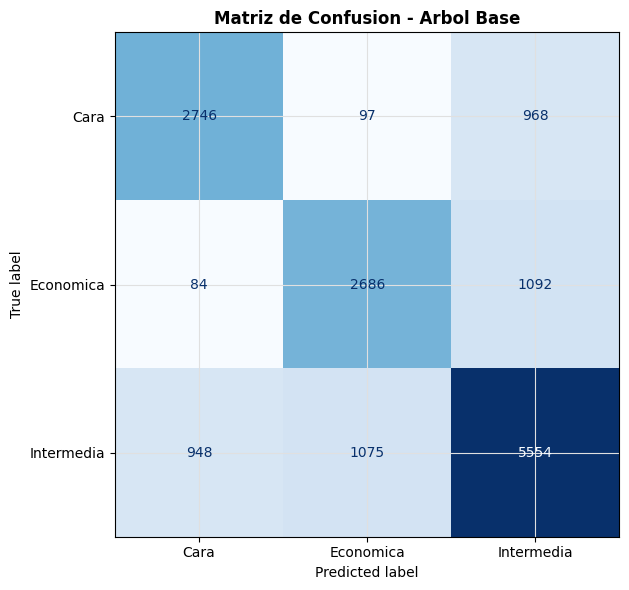

In [152]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=clf_base['metrics']['conf_matrix'],
    display_labels=["Cara", "Economica", "Intermedia"]
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Matriz de Confusion - Arbol Base", fontweight="bold")
plt.tight_layout()
plt.show()

### Analisis de la Matriz de Confusion - Arbol Base

**Efectividad general:** el modelo clasifica correctamente el 72% de los casos (accuracy=0.72),
con un desempeno desigual entre clases.

**Donde el modelo acierta mas:**
- Intermedia: 5,554 de 7,577 correctas (73.3%) -> esperado, es la clase mayoritaria
- Cara: 2,746 de 3,811 correctas (72.0%)
- Economica: 2,686 de 3,862 correctas (69.5%)

**Donde el modelo se equivoca mas:**
El error mas frecuente en las tres clases es la confusion con Intermedia:
- 968 propiedades Caras clasificadas como Intermedias (25.4% de las Caras)
- 1,092 propiedades Economicas clasificadas como Intermedias (28.3% de las Economicas)
- 1,075 propiedades Intermedias clasificadas como Economica o Cara (14.2%)

Esto es estructuralmente esperado: Intermedia ocupa el rango central ($120-$326) y
actua como zona de absorcion de errores en los limites de ambas clases extremas.
Propiedades en el borde de $120 o $326 son inherentemente ambiguas.

**Importancia de los errores:**
La confusion Cara -> Intermedia es el error mas costoso para SmartStay: implica
subestimar el segmento premium, lo que podria llevar a recomendar propiedades
de lujo a clientes con presupuesto estandar. La confusion Economica -> Intermedia
tiene el impacto inverso pero igualmente problematico para la experiencia del cliente.

La confusion entre Cara y Economica es muy baja (97 y 84 casos respectivamente),
lo que indica que el modelo distingue bien los extremos del mercado.

In [153]:
clf_cv = run_tree(
    X_train_clf, X_test_clf, y_train_clf, y_test_clf,
    task="classification",
    cv=5
)

print("Arbol de Clasificacion - Validacion Cruzada (5 folds)")
print(f"  Accuracy en test:  {clf_cv['metrics']['accuracy']:.4f}")
print(f"  Profundidad real:  {clf_cv['model'].get_depth()}")
print(f"  Numero de hojas:   {clf_cv['model'].get_n_leaves()}")

Arbol de Clasificacion - Validacion Cruzada (5 folds)
  Accuracy en test:  0.7204
  Profundidad real:  43
  Numero de hojas:   9842


### Modelo con Validacion Cruzada (5 folds)

El modelo entrenado con validacion cruzada de 5 folds produce exactamente la misma
accuracy (0.7204), profundidad (43) y numero de hojas (9,842) que el modelo base.

Esto es esperado: la validacion cruzada no modifica la arquitectura del arbol ni sus
hiperparametros, sino que evalua la estabilidad del modelo entrenando y validando sobre
5 particiones distintas del conjunto de entrenamiento. El modelo final se ajusta sobre
todo X_train y se evalua sobre X_test, por lo que el resultado en test es identico.

La utilidad de la validacion cruzada en este contexto es confirmar que el modelo no
depende de una particion especifica de los datos — si los 5 folds producen accuracies
similares, el modelo es estable. Sin embargo, sin limite de profundidad el overfitting
persiste independientemente del esquema de validacion utilizado.

El siguiente paso es tunear max_depth para encontrar el modelo con mejor generalizacion.

In [155]:
clf_models = {
    "Base (sin limite)": clf_base,
    "CV (sin limite)":   clf_cv
}

for d in DEPTHS:
    clf_models[f"max_depth={d}"] = run_tree(
        X_train_clf, X_test_clf, y_train_clf, y_test_clf,
        task="classification",
        max_depth=d,
        cv=5
    )

clf_results_df = pd.DataFrame([
    {
        "Modelo":    name,
        "max_depth": res["max_depth"] if res["max_depth"] else 43,
        "Accuracy":  round(res["metrics"]["accuracy"], 4)
    }
    for name, res in clf_models.items()
])

print(clf_results_df.to_string(index=False))

           Modelo  max_depth  Accuracy
Base (sin limite)         43    0.7204
  CV (sin limite)         43    0.7204
      max_depth=5          5    0.6670
     max_depth=10         10    0.7222
     max_depth=20         20    0.7282


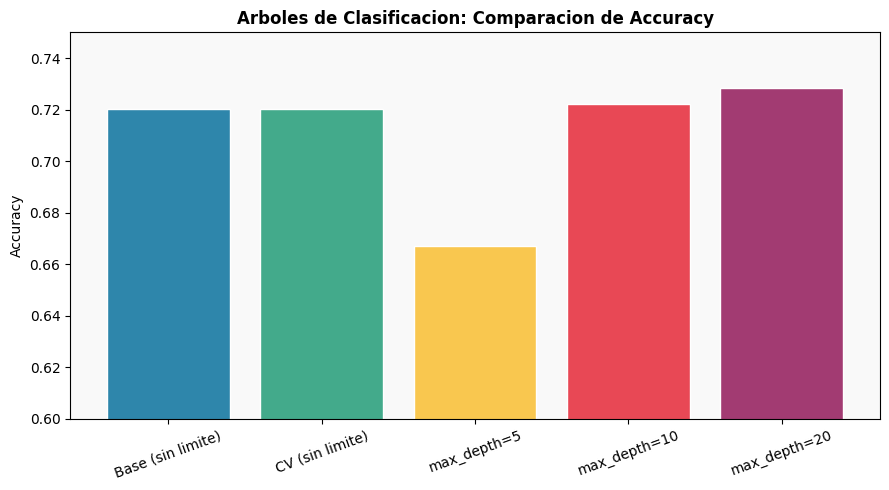

In [157]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#2E86AB', '#43AA8B', '#F9C74F', '#E84855', '#A23B72']
ax.bar(clf_results_df["Modelo"], clf_results_df["Accuracy"], color=colors, edgecolor='white')
ax.set_title("Arboles de Clasificacion: Comparacion de Accuracy", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.6, 0.75)
ax.tick_params(axis='x', rotation=20)

plt.grid(False)
plt.tight_layout()
plt.show()

### Tuneo de profundidad - Arbol de Clasificacion

Los cinco modelos muestran que la profundidad tiene un impacto claro en la accuracy
de clasificacion, con un patron distinto al observado en regresion.

max_depth=5 es el peor modelo con 66.7% de accuracy. Con solo 5 niveles el arbol
no tiene suficiente capacidad para distinguir entre las tres categorias de precio,
especialmente la clase Intermedia que requiere condiciones mas complejas.

max_depth=10 (72.2%) es practicamente identico al modelo base (72.0%), lo que
indica que con 10 niveles el arbol ya captura la mayoria de los patrones relevantes.

max_depth=20 es el mejor modelo con 72.8% de accuracy, superando marginalmente al
base. A diferencia de regresion donde profundidades altas empeoraban el RMSE por
overfitting en outliers de precio, en clasificacion el modelo se beneficia de mayor
profundidad porque las fronteras entre clases son mas complejas.

Sin embargo, la diferencia entre max_depth=10 (72.2%) y max_depth=20 (72.8%) es
de apenas 0.6 puntos porcentuales. Considerando que max_depth=20 genera un arbol
significativamente mas complejo y menos interpretable, max_depth=10 ofrece el
mejor balance entre accuracy y simplicidad.

Seleccion: max_depth=20 como mejor modelo por accuracy, con max_depth=10 como
alternativa preferible si se prioriza interpretabilidad.

# Random Forest 

In [158]:
def run_forest(X_train, X_test, y_train, y_test,
               task="regression",
               max_depth=None,
               n_estimators=100,
               random_state=SEED):

    if task == "regression":
        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state
        )
    elif task == "classification":
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state
        )
    else:
        raise ValueError(f"task debe ser 'regression' o 'classification', recibido: {task}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if task == "regression":
        metrics = {
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "mae":  mean_absolute_error(y_test, y_pred),
            "r2":   r2_score(y_test, y_pred)
        }
    else:
        metrics = {
            "accuracy":    accuracy_score(y_test, y_pred),
            "report":      classification_report(y_test, y_pred, output_dict=True),
            "conf_matrix": confusion_matrix(y_test, y_pred)
        }

    return {
        "model":     model,
        "y_pred":    y_pred,
        "metrics":   metrics,
        "task":      task,
        "max_depth": max_depth,
        "n_estimators": n_estimators
    }

## Regression

In [161]:
rf_reg_base = run_forest(X_train, X_test, y_train, y_test, task="regression")

rf_reg_models = {"Base (sin limite)": rf_reg_base}

for d in DEPTHS:
    rf_reg_models[f"max_depth={d}"] = run_forest(
        X_train, X_test, y_train, y_test,
        task="regression",
        max_depth=d
    )

rf_reg_results_df = pd.DataFrame([
    {
        "Modelo":  name,
        "RMSE":    round(res["metrics"]["rmse"], 2),
        "MAE":     round(res["metrics"]["mae"], 2),
        "R2":      round(res["metrics"]["r2"], 4)
    }
    for name, res in rf_reg_models.items()
])

print(rf_reg_results_df.to_string(index=False))


           Modelo    RMSE    MAE     R2
Base (sin limite) 1437.36 203.18 0.8891
      max_depth=5 1768.63 359.19 0.8321
     max_depth=10 1443.87 236.86 0.8881
     max_depth=20 1434.85 206.82 0.8895


## Classifier

In [162]:
rf_clf_base = run_forest(
    X_train_clf, X_test_clf, y_train_clf, y_test_clf,
    task="classification"
)

rf_clf_models = {"Base (sin limite)": rf_clf_base}

for d in DEPTHS:
    rf_clf_models[f"max_depth={d}"] = run_forest(
        X_train_clf, X_test_clf, y_train_clf, y_test_clf,
        task="classification",
        max_depth=d
    )

rf_clf_results_df = pd.DataFrame([
    {
        "Modelo":   name,
        "Accuracy": round(res["metrics"]["accuracy"], 4)
    }
    for name, res in rf_clf_models.items()
])

print(rf_clf_results_df.to_string(index=False))

           Modelo  Accuracy
Base (sin limite)    0.7946
      max_depth=5    0.6751
     max_depth=10    0.7420
     max_depth=20    0.7913


In [163]:
comparison_reg = pd.DataFrame([
    {"Algoritmo": "Arbol (base)",       "RMSE": 1713.52, "MAE": 226.10, "R2": 0.8424},
    {"Algoritmo": "Arbol (max_depth=10)","RMSE": 1735.91, "MAE": 237.48, "R2": 0.8382},
    {"Algoritmo": "Arbol (max_depth=20)","RMSE": 1769.68, "MAE": 224.92, "R2": 0.8319},
    {"Algoritmo": "RF (base)",          "RMSE": rf_reg_base['metrics']['rmse'],  "MAE": rf_reg_base['metrics']['mae'],  "R2": rf_reg_base['metrics']['r2']},
    {"Algoritmo": "RF (max_depth=20)",  "RMSE": rf_reg_models['max_depth=20']['metrics']['rmse'], "MAE": rf_reg_models['max_depth=20']['metrics']['mae'], "R2": rf_reg_models['max_depth=20']['metrics']['r2']},
    {"Algoritmo": "Reg. Lineal (mejor)","RMSE": 3484.82, "MAE": 1104.43, "R2": 0.3481},
])

print(comparison_reg.to_string(index=False))

           Algoritmo        RMSE         MAE       R2
        Arbol (base) 1713.520000  226.100000 0.842400
Arbol (max_depth=10) 1735.910000  237.480000 0.838200
Arbol (max_depth=20) 1769.680000  224.920000 0.831900
           RF (base) 1437.357658  203.179583 0.889098
   RF (max_depth=20) 1434.854368  206.822598 0.889484
 Reg. Lineal (mejor) 3484.820000 1104.430000 0.348100


In [164]:
comparison_clf = pd.DataFrame([
    {"Algoritmo": "Arbol (base)",        "Accuracy": 0.7204},
    {"Algoritmo": "Arbol (max_depth=10)","Accuracy": 0.7222},
    {"Algoritmo": "Arbol (max_depth=20)","Accuracy": 0.7282},
    {"Algoritmo": "RF (base)",           "Accuracy": rf_clf_base['metrics']['accuracy']},
    {"Algoritmo": "RF (max_depth=20)",   "Accuracy": rf_clf_models['max_depth=20']['metrics']['accuracy']},
])

print(comparison_clf.to_string(index=False))

           Algoritmo  Accuracy
        Arbol (base)  0.720400
Arbol (max_depth=10)  0.722200
Arbol (max_depth=20)  0.728200
           RF (base)  0.794557
   RF (max_depth=20)  0.791279


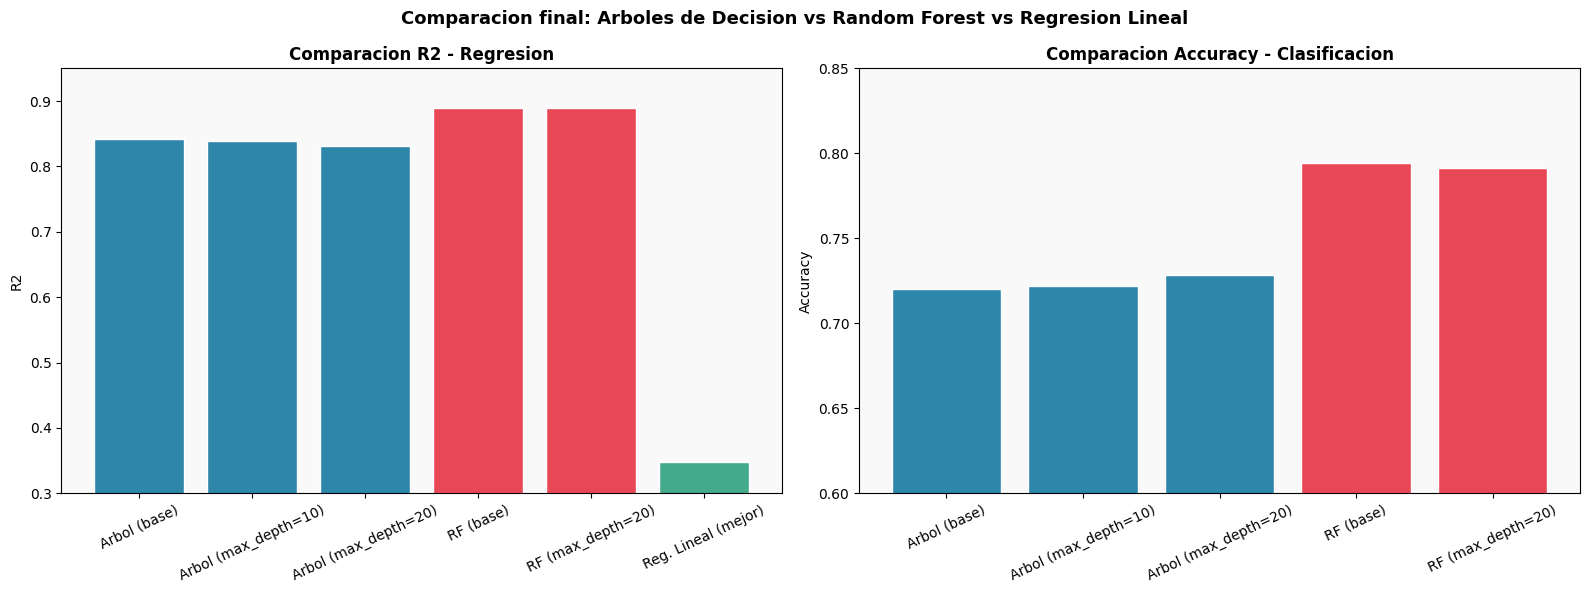

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regresion - R2
colors_reg = ['#2E86AB']*3 + ['#E84855']*2 + ['#43AA8B']
axes[0].bar(comparison_reg["Algoritmo"], comparison_reg["R2"], color=colors_reg, edgecolor='white')
axes[0].set_title("Comparacion R2 - Regresion", fontweight="bold")
axes[0].set_ylabel("R2")
axes[0].set_ylim(0.3, 0.95)
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(False)

# Clasificacion - Accuracy
colors_clf = ['#2E86AB']*3 + ['#E84855']*2
axes[1].bar(comparison_clf["Algoritmo"], comparison_clf["Accuracy"], color=colors_clf, edgecolor='white')
axes[1].set_title("Comparacion Accuracy - Clasificacion", fontweight="bold")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.6, 0.85)
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(False)

plt.suptitle("Comparacion final: Arboles de Decision vs Random Forest vs Regresion Lineal",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Comparacion Final de Algoritmos

### Regresion (prediccion de precio)

| Algoritmo            | RMSE     | MAE      | R2     |
|----------------------|----------|----------|--------|
| Reg. Lineal (mejor)  | $3,484   | $1,104   | 0.3481 |
| Arbol (base)         | $1,713   | $226     | 0.8424 |
| Arbol (max_depth=10) | $1,735   | $237     | 0.8382 |
| Arbol (max_depth=20) | $1,769   | $224     | 0.8319 |
| RF (base)            | $1,437   | $203     | 0.8891 |
| RF (max_depth=20)    | $1,434   | $206     | 0.8895 |

Random Forest es el mejor algoritmo de regresion en todas las metricas. El RF con
max_depth=20 reduce el RMSE en ~$279 respecto al mejor arbol individual y mejora
el R2 de 0.84 a 0.89. La ventaja sobre la regresion lineal es contundente: RF
reduce el RMSE en ~$2,050 (~59%) y triplica el R2.

La superioridad de RF se explica por su capacidad de capturar interacciones no
lineales entre variables mediante el promedio de 100 arboles, reduciendo la
varianza del modelo sin aumentar el sesgo significativamente.

### Clasificacion (prediccion de categoria de precio)

| Algoritmo            | Accuracy |
|----------------------|----------|
| Arbol (base)         | 72.0%    |
| Arbol (max_depth=10) | 72.2%    |
| Arbol (max_depth=20) | 72.8%    |
| RF (base)            | 79.5%    |
| RF (max_depth=20)    | 79.1%    |

Random Forest supera al mejor arbol individual en ~6.7 puntos porcentuales de
accuracy (79.5% vs 72.8%). El RF base es marginalmente mejor que RF max_depth=20,
lo que indica que sin limite de profundidad el ensamble de arboles generaliza
mejor que con arboles podados.

### Conclusion general

Random Forest es el mejor algoritmo para ambas tareas en este dataset. Su ventaja
principal sobre los arboles individuales es la reduccion de varianza mediante el
ensamble: donde un arbol individual puede sobreajustarse a patrones especificos
del entrenamiento, RF promedia las predicciones de 100 arboles entrenados en
subsets distintos, produciendo predicciones mas estables y precisas.

Para SmartStay Advisors se recomienda RF base como modelo de produccion tanto
para estimar precios como para clasificar propiedades, por su balance entre
precision y capacidad de generalizacion sobre datos nuevos.